In [2]:
import numpy as np
import matplotlib.pyplot as plt
import os
import sys
import sharpy.cases.templates.flying_wings as wings
import sharpy.sharpy_main
import sharpy.utils.plotutils as pu

In [3]:
speed = 34
u_inf = speed #m/s
alpha_deg = 5
rho = 1.225

number_chordwise_panels = 16
number_spanwise_nodes = 32
wake_length_factor = 10

cases_folder = './cases/' # folder to store input files
output_folder = './output' # folder to save results
route_notebook_dir =  os.path.abspath('')

In [4]:
case_name = "Dynamic_ThickerPID13"
route_test_dir = os.path.abspath('')

length = 1.2
width = 0.06
height = 0.004
c_ref= 0.2
massperunit = 1.8
massweight = 0.1
simulation_time=3.0

pazy_altered = wings.PazyControlSurface(
    M = number_chordwise_panels,
    N = number_spanwise_nodes,
    Mstar_fact=wake_length_factor,
    u_inf=u_inf,
    alpha=alpha_deg,
    cs_deflection=[0,0],
    n_control_surfaces=2,
    rho=rho,
    tip_rod=False,
    b_ref=2.*length,
    main_chord=c_ref,
    pct_flap=0.2,
    aspect_ratio=2*length/c_ref,
    n_surfaces=2,
    route = cases_folder + '/' + case_name,
    case_name=case_name,
    physical_time = simulation_time,
    cs_type = 2
)

In [5]:
def new_update_mass_stiff(self):
    import sharpy.utils.algebra as algebra

    #seeing our wing has roughly 2% of the area of the goland wing we have to scale the 
    #structural properties appropriately to achieve flutter, (as lift forces are proportional
    #to the wing area)
    E = 69e9  # Young's modulus in Pascals (Pa)
    G = 26e9  # Shear modulus in Pascals (Pa)
    rho = 2700

    # Cross-sectional properties
    A = width * height  # Area in m²
    Iy = (width * height**3) / 12  # Second moment of area about the y-axis (m⁴)
    Iz = (height * width**3) / 12  # Second moment of area about the z-axis (m⁴)
    print(Iy)
    print(Iz)
    J = 2*height**3*width/3  # Torsion constant approximation for rectangular section

    # Rigidity calculations
    EA = E * A
    GA = G * A
    GJ = G * J
    EIy = E * Iy
    EIz = E * Iz

    ea, ga = EA, GA
    gj = GJ
    eiy = EIy
    eiz = EIz
    base_stiffness = np.diag([ea, ga, ga, gj, eiy, eiz])
    self.stiffness = np.zeros((1, 6, 6))
    self.stiffness[0] = base_stiffness
    print(base_stiffness)
    
    m_unit = massperunit
    j_tors = (Iy+Iz)*rho
    print(Iy+Iz)
    print(j_tors)
    pos_cg_b = np.array([0., self.c_ref * (self.main_cg - self.main_ea), 0.])
    m_chi_cg = algebra.skew(m_unit * pos_cg_b)
    self.mass = np.zeros((1, 6, 6))
    self.mass[0, :, :] = np.diag([m_unit, m_unit, m_unit,
                                    j_tors, .1 * j_tors, .9 * j_tors])

    self.mass[0, :3, 3:] = m_chi_cg
    self.mass[0, 3:, :3] = -m_chi_cg

    self.elem_stiffness = np.zeros((self.num_elem_tot,), dtype=int)
    self.elem_mass = np.zeros((self.num_elem_tot,), dtype=int)

    n_lumped_mass = 2
    self.lumped_mass = np.zeros((n_lumped_mass))
    self.lumped_mass_position = np.zeros((n_lumped_mass, 3))
    self.lumped_mass_inertia = np.zeros((n_lumped_mass, 3, 3))
    self.lumped_mass_nodes = np.zeros((n_lumped_mass), dtype=int)

    #positive y is towards back
    self.lumped_mass[0] = massweight
    self.lumped_mass_position[0] = np.array([0, 0.5, 0])
    self.lumped_mass_nodes[0] = self.N//2
    self.lumped_mass_inertia[0, :, :] = np.diag([1.2815E-04, 2.87E-07, 1.17E-04])

    self.lumped_mass[1] = massweight
    self.lumped_mass_position[1] = np.array([0, 0.5, 0])
    self.lumped_mass_nodes[1] = self.N//2+1
    self.lumped_mass_inertia[1, :, :] = np.diag([1.2815E-04, 2.87E-07, 1.17E-04])

    self.main_ea = 0.33
    self.main_cg = 0.43

pazy_altered.update_mass_stiff = new_update_mass_stiff.__get__(pazy_altered, wings.PazyControlSurface) 

In [6]:
pazy_altered.clean_test_files()
pazy_altered.update_derived_params()
pazy_altered.set_default_config_dict()

pazy_altered.generate_aero_file()
pazy_altered.generate_fem_file()

3.2e-10
7.2e-08
[[1.656e+07 0.000e+00 0.000e+00 0.000e+00 0.000e+00 0.000e+00]
 [0.000e+00 6.240e+06 0.000e+00 0.000e+00 0.000e+00 0.000e+00]
 [0.000e+00 0.000e+00 6.240e+06 0.000e+00 0.000e+00 0.000e+00]
 [0.000e+00 0.000e+00 0.000e+00 6.656e+01 0.000e+00 0.000e+00]
 [0.000e+00 0.000e+00 0.000e+00 0.000e+00 2.208e+01 0.000e+00]
 [0.000e+00 0.000e+00 0.000e+00 0.000e+00 0.000e+00 4.968e+03]]
7.232e-08
0.000195264


In [ ]:
#pid setup
gains = [4, 0.5, 0]
tip_file = route_test_dir + '/tip_vel.csv'
tip_hist = np.linspace(0.0, 0.0, pazy_altered.n_tstep) #velocity
np.savetxt(tip_file, tip_hist)

In [8]:
rom_settings = dict()
rom_settings['algorithm'] = 'mimo_rational_arnoldi'  # reduction algorithm
rom_settings['r'] = 6  # Krylov subspace order
frequency_continuous_k = np.array([0.])  # Interpolation point in the complex plane with reduced frequency units
frequency_continuous_w = 2 * u_inf * frequency_continuous_k / c_ref
rom_settings['frequency'] = frequency_continuous_w

pazy_altered.set_default_config_dict()
pazy_altered.config['SHARPy'] = {
    'flow':
    [
        'BeamLoader',
        'AerogridLoader',
        'StaticCoupled',
        'AerogridPlot',
        'BeamPlot',
        'DynamicCoupled',
    ],
    'case': pazy_altered.case_name, 'route' : pazy_altered.route,
    'write_screen': 'on', 'write_log': 'on',
    'save_settings' : 'on',
    'log_folder': output_folder + '/',
    'log_file': pazy_altered.case_name+'.log'
    }

pazy_altered.config['BeamLoader'] = {
    'unsteady': 'off',
    'orientation': pazy_altered.quat
}

pazy_altered.config['AerogridLoader'] = {
    'unsteady': 'on',
    'aligned_grid': 'on',
    'mstar': wake_length_factor*pazy_altered.M,
    'wake_shape_generator': 'StraightWake',
    'wake_shape_generator_input': {
        'u_inf':pazy_altered.u_inf,
        'u_inf_direction': [1., 0., 0.], 
        'dt': pazy_altered.dt, 
    }, 
} 
 
pazy_altered.config['StaticCoupled'] = { 
        'print_info': 'on', 
        'max_iter': 200, 
        'n_load_steps': 5, 
        'tolerance': 1e-5,
        'relaxation_factor': 0.1,
        'aero_solver': 'StaticUvlm',
        'aero_solver_settings': {
            'rho': pazy_altered.rho,
            'print_info': 'off',
            'horseshoe': 'on',
            'num_cores': 4,
            'n_rollup': 0,
            'velocity_field_generator': 'SteadyVelocityField',
            'velocity_field_input': {
                'u_inf': pazy_altered.u_inf,
                'u_inf_direction': pazy_altered.u_inf_direction},
            'vortex_radius': 1e-9},
        'structural_solver': 'NonLinearStatic',
        'structural_solver_settings': {'print_info': 'off',
                                   'max_iterations': 200,
                                   'num_load_steps': 5,
                                   'delta_curved': 1e-6,
                                   'min_delta': 1e-8,
                                   'gravity': True,
                                   'gravity': 9.81},
    }
pazy_altered.config['AerogridPlot'] = {'include_rbm': 'off',
                                               'include_applied_forces': 'on',
                                               'minus_m_star': 0}

pazy_altered.config['BeamPlot'] = {'include_rbm': 'off',
                                           'include_applied_forces': 'on'}
    
pazy_altered.config['WriteVariablesTime'] = {'structure_variables': ['pos'],
                                                     'structure_nodes': list(range(0, pazy_altered.num_node_surf)),
                                                     'cleanup_old_solution': 'on',}

pazy_altered.config['DynamicCoupled'] = {'print_info': 'on',
                                  'structural_substeps': 10,
                                  'dynamic_relaxation': 'on',
                                  'cleanup_previous_solution': 'on',
                                  'structural_solver': 'NonLinearDynamicPrescribedStep',
                                  'structural_solver_settings':  {'print_info': 'off',
                                                                'max_iterations': 950,
                                                                'delta_curved': 1e-1,
                                                                'min_delta': 1e-6,
                                                                'newmark_damp': 0.5e-4,
                                                                'gravity': True,
                                                                'gravity': 9.81,
                                                                'num_steps': pazy_altered.n_tstep,
                                                                'dt':pazy_altered.dt,
                                                                },
                                  'aero_solver': 'StepUvlm',
                                  'aero_solver_settings':  {'print_info': 'on',
                                                            'num_cores': 4,
                                                            'convection_scheme': 2,
                                                            'velocity_field_generator': 'SteadyVelocityField',
                                                            'velocity_field_input': {'u_inf': pazy_altered.u_inf,
                                                                                    'u_inf_direction': [1., 0., 0.]},
                                                            'rho': pazy_altered.rho,
                                                            'n_time_steps': pazy_altered.n_tstep,
                                                            'vortex_radius': 1e-9,
                                                            'dt': pazy_altered.dt,
                                                            'gamma_dot_filtering': 3},
                                  'controller_id': {'controller_tip': 'ControlSurfacePidController'},
                                  'controller_settings': {'controller_tip': {'P': gains[0],
                                                                             'I': gains[1],
                                                                             'D': gains[2],
                                                                             'dt': pazy_altered.dt,
                                                                             'N': pazy_altered.N,
                                                                             'input_type': 'tip_pos',
                                                                             'controlled_surfaces': [0,1],
                                                                             'time_history_input_file': 'tip_vel.csv'}},
                                  'fsi_substeps': 200,
                                  'fsi_tolerance': 1e-6,
                                  'relaxation_factor': pazy_altered.relaxation_factor,
                                  'minimum_steps': 1,
                                  'relaxation_steps': 150,
                                  'final_relaxation_factor': 0.0,
                                  'n_time_steps': pazy_altered.n_tstep,
                                  'dt': pazy_altered.dt,
                                  'include_unsteady_force_contribution':  True,
                                  'postprocessors': ['WriteVariablesTime', 'BeamPlot', 'AerogridPlot'],
                                  'postprocessors_settings': {'BeamPlot': {'include_rbm': 'on',
                                                                           'include_applied_forces': 'on'},
                                                              'StallCheck': {},
                                                              'AerogridPlot': {
                                                                  'u_inf': pazy_altered.u_inf,
                                                                  'include_rbm': 'on',
                                                                  'include_applied_forces': 'on',
                                                                  'minus_m_star': 0},
                                                              'WriteVariablesTime': {
                                                                  'structure_variables': ['pos', 'psi'],
                                                                  'structure_nodes': [pazy_altered.num_node_surf - 1,
                                                                                      pazy_altered.num_node_surf,
                                                                                      pazy_altered.num_node_surf + 1],
                                                                    },
                                                                    },
                                    'network_settings': {},
                                    }

pazy_altered.config['PickleData'] = {}
pazy_altered.config['LinearAssembler'] = {'linear_system': 'LinearAeroelastic',
                                    'inout_coordinates': 'nodes', 
                                    # 'recover_accelerations': True,           
                                'linear_system_settings': {
                                    'beam_settings': {'modal_projection': True,
                                                        'inout_coords': 'modes',
                                                        'discrete_time': True,
                                                        'newmark_damp': 0.5e-4,
                                                        'discr_method': 'newmark',
                                                        'dt': pazy_altered.dt,
                                                        'proj_modes': 'undamped',
                                                        'num_modes': 20,
                                                        'print_info': 'on',
                                                        'gravity': True,
                                                        'remove_dofs': []},
                                    'aero_settings': {'dt': pazy_altered.dt,
                                                        'integr_order': 2,
                                                        'density': pazy_altered.rho,
                                                        'remove_predictor': True,
                                                        'use_sparse': 'off',
                                                        'gust_assembler':  'LeadingEdge',
                                                        'ScalingDict': {'length':1, 'speed': 1, 'density': 1},
                                                        },
                                    'track_body': False,
                                    'use_euler': False,
                                    }}
pazy_altered.config['Modal'] = {'print_info': True,
                            'use_undamped_modes': True,
                            'NumLambda': 20,
                            'rigid_body_modes': False, 
                            'write_modes_vtk': False,
                            'print_matrices': False,
                            'continuous_eigenvalues': 'off',
                            'dt': pazy_altered.dt,
                            'plot_eigenvalues': False,
                            }
pazy_altered.config['SaveData']['save_linear'] = True

pazy_altered.config.write()

In [ ]:
sharpy.sharpy_main.main(['', pazy_altered.route + pazy_altered.case_name + '.sharpy'])

--------------------------------------------------------------------------------
            ######  ##     ##    ###    ########  ########  ##    ##
           ##    ## ##     ##   ## ##   ##     ## ##     ##  ##  ##
           ##       ##     ##  ##   ##  ##     ## ##     ##   ####
            ######  ######### ##     ## ########  ########     ##
                 ## ##     ## ######### ##   ##   ##           ##
           ##    ## ##     ## ##     ## ##    ##  ##           ##
            ######  ##     ## ##     ## ##     ## ##           ##
--------------------------------------------------------------------------------
Aeroelastics Lab, Aeronautics Department.
    Copyright (c), Imperial College London.
    All rights reserved.
    License available at https://github.com/imperialcollegelondon/sharpy
Running SHARPy from /home/password/sharpy/sharpy
SHARPy being run is in /home/password/.local/lib/python3.10/site-packages
SHARPy output folder set
	./output//Dynamic_ThickerPID13/
Gener

fatal: not a git repository (or any of the parent directories): .git


|  0  |  0  |  0.00000   | -2.2341  |  0.0000  | 30.0233  | -0.0000  |  0.4050  | -0.0000  |
|  1  |  0  |  -4.84688  | -2.2741  |  0.0000  | 30.3090  | -0.0000  |  0.4085  | -0.0000  |
|  2  |  0  |  -5.74951  | -2.2790  |  0.0000  | 30.3439  | -0.0000  |  0.4089  | -0.0000  |
|  0  |  1  |  0.00000   | -4.4941  |  0.0000  | 59.5555  | -0.0000  |  0.5960  | -0.0000  |
|  1  |  1  |  -4.23364  | -4.4528  |  0.0000  | 59.3488  | -0.0001  |  0.6045  | -0.0000  |
|  2  |  1  |  -5.65212  | -4.4522  |  0.0001  | 59.3503  | -0.0001  |  0.6050  | -0.0000  |
|  0  |  2  |  0.00000   | -6.6079  |  0.0001  | 86.2590  | -0.0001  |  0.5799  | -0.0000  |
|  1  |  2  |  -3.44271  | -6.3801  |  0.0002  | 85.0837  | -0.0002  |  0.6244  | -0.0000  |
|  2  |  2  |  -5.19285  | -6.3857  |  0.0002  | 85.1215  | -0.0002  |  0.6239  | -0.0000  |
|  0  |  3  |  0.00000   | -8.4523  |  0.0004  | 108.7816 | -0.0002  |  0.4247  | -0.0000  |
|  1  |  3  |  -3.03133  | -7.9806  |  0.0007  | 106.6662 | -0.0005  |

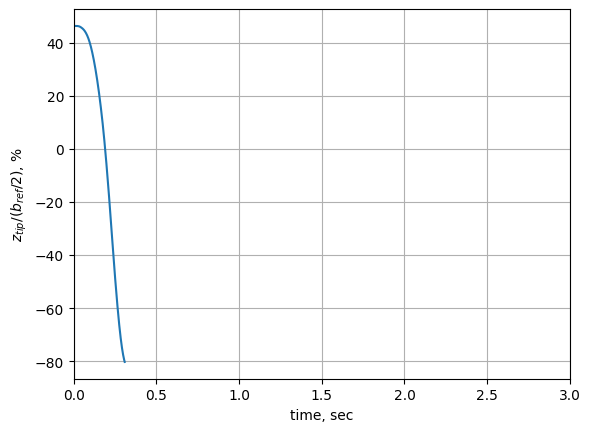

In [9]:
def get_resulting_vertical_tip_displacement(output_folder, model):    
    file_results = os.path.join(output_folder, 
                                 model.case_name, 
                                 'WriteVariablesTime',
                                 'struct_pos_node{}.dat'.format(model.num_node_surf))
    vertical_tip_displacement = np.loadtxt(file_results)[:,-1]
    
                                             
    return vertical_tip_displacement
 

tip_displacement_open_loop = get_resulting_vertical_tip_displacement(output_folder, 
                                                                     pazy_altered)


time_array = np.arange(0, len(tip_displacement_open_loop) * pazy_altered.dt, pazy_altered.dt)
normalised_tip_displacement = tip_displacement_open_loop/ (0.5*pazy_altered.b_ref) #normalise by half wing span
normalised_tip_displacement *=100# cconvert to percentnvert to percent
plt.plot(time_array, normalised_tip_displacement)
plt.xlabel('time, sec')
plt.ylabel('$z_{tip}/(b_{ref}/2)$, %')
plt.xlim([0., simulation_time])
plt.grid()
plt.show()

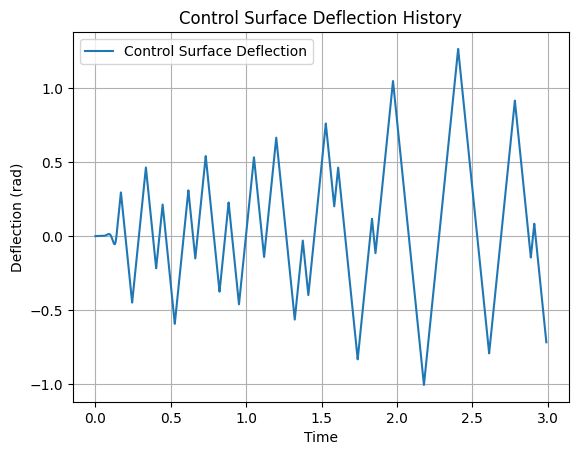

In [ ]:
#show control surface deflection history
data = np.loadtxt(output_folder+'/'+pazy_altered.case_name+'/controllers/controller_tip.log.csv', delimiter=',', skiprows=1)
time = data[:, 1]  # Second column: time
control_deflections = data[:, -1]  # Last column: control surface deflection
plt.plot(time, control_deflections, label='Control Surface Deflection')
plt.xlabel('Time')
plt.ylabel('Deflection (rad)')
plt.title('Control Surface Deflection History')
plt.legend()
plt.grid()
plt.show()


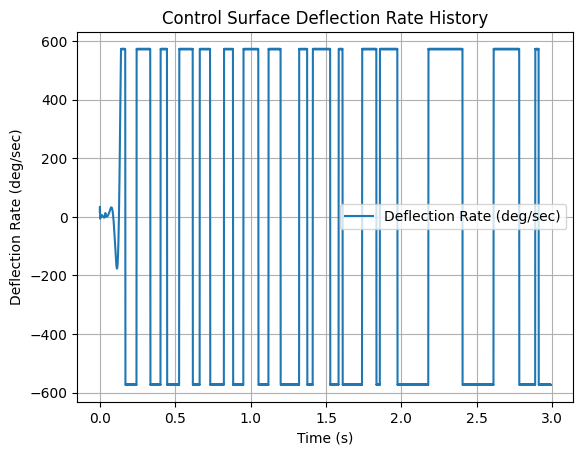

In [ ]:
# Compute control surface deflection rate (radians per second)
deflection_rate_rad = np.gradient(control_deflections, time)

# Convert to degrees per second
deflection_rate_deg = deflection_rate_rad * 57.2958

# Plot
plt.plot(time, deflection_rate_deg, label='Deflection Rate (deg/sec)')
plt.xlabel('Time (s)')
plt.ylabel('Deflection Rate (deg/sec)')
plt.title('Control Surface Deflection Rate History')
plt.legend()
plt.grid()
plt.show()